In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import random
import math

In [2]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x25929700380>)

In [3]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [4]:
#There are 6 star types that are encoded in the 'Star type' column. 
#These labels are currently encoded as strings which is practical for reading but not for computing. Using scikit-learn, 
#we will convert this column into integers by assigning a unique int value to each star type
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


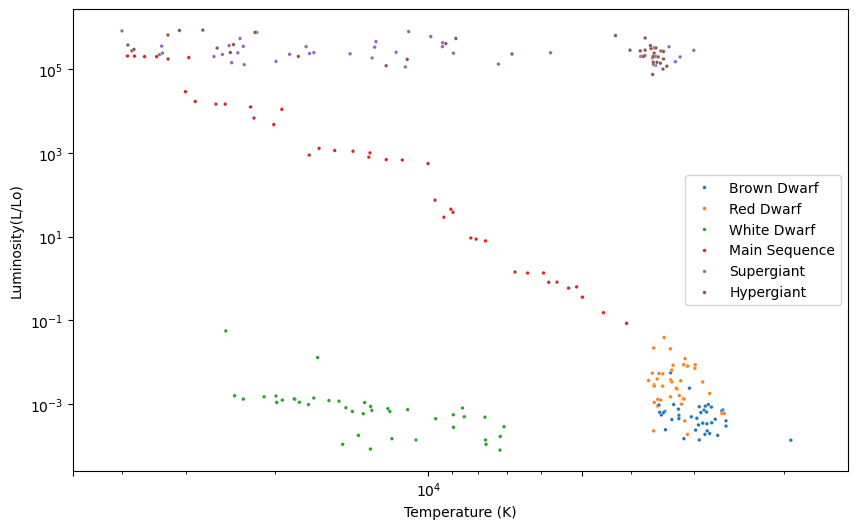

In [79]:
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', s=7, hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

# PCA

In [69]:
from sklearn.decomposition import PCA

#I clean the data to do proer PCA
X = df_stars.drop(['Star type','Star color','Spectral Class'],axis=1)
n_components = 2
pca = PCA(n_components) # n_components 
pca.fit(X) 

eigenvalues = pca.transform(X) # compute the subspace projection of X, n_components eigenvalues for each of the samples
mean = pca.mean_ # length 4 mean of the data
eigenvectors = pca.components_ # n_componentsx4 matrix of components, multiply each by respective eigenvalue to reconstruct

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors*eigenvalues[0]

print(eigenvalues.shape)
print(eigenvectors.shape)

(240, 2)
(2, 4)


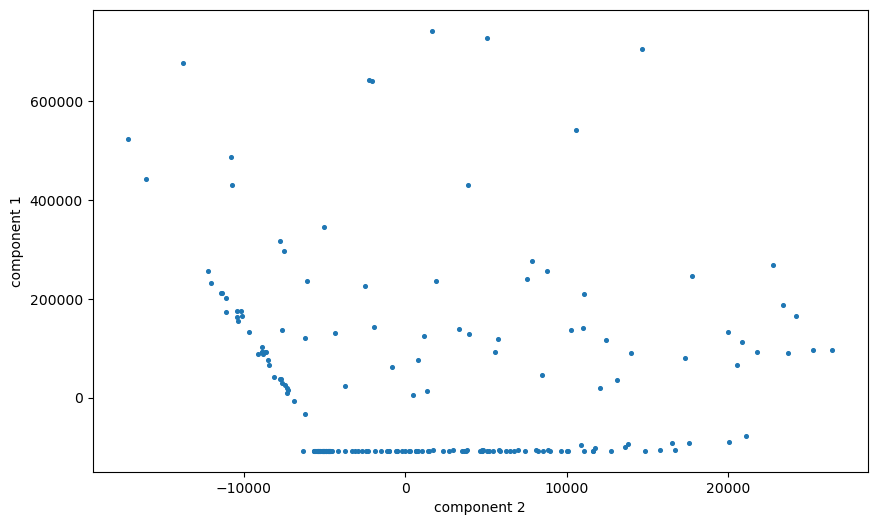

In [78]:
comp = pca.fit_transform(X) #eigevalues*eigenvectors

plt.figure(figsize=(10,6))
plt.scatter(comp[:,1],comp[:,0], s=7)
plt.ylabel('component 1')
plt.xlabel('component 2')
plt.show()

It looks bad but because I need to rescale my data so "the algorithm can see what I see" in the HR dyagram

## rescaling

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(X)

In [72]:
pca_new = PCA(n_components) # n_components 
pca_new.fit(data) 

eigenvalues_new = pca_new.transform(data)
mean_new = pca_new.mean_
eigenvectors_new = pca_new.components_

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors*eigenvalues[0]

print(eigenvalues_new.shape)
print(eigenvectors_new.shape)

comp_new = pca_new.fit_transform(data)

(240, 2)
(2, 4)


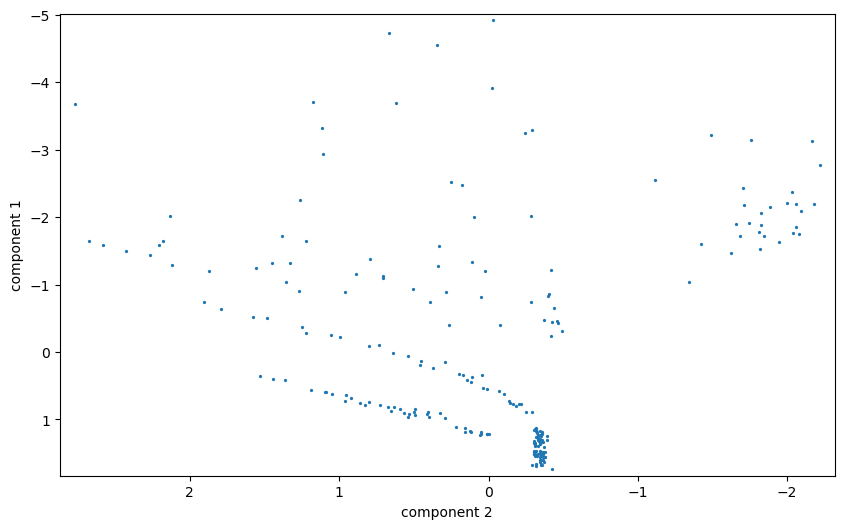

In [77]:
plt.figure(figsize=(10,6))
plt.scatter(comp_new[:,1],comp_new[:,0], marker='.', s=7)
plt.xlim(np.max(comp_new[:,1])+0.1,np.min(comp_new[:,1])-0.1)
plt.ylim(np.max(comp_new[:,0])+0.1,np.min(comp_new[:,0])-0.1)
plt.ylabel('component 1')
plt.xlabel('component 2')
plt.show()

Very good! I can visually see different groups. Let's compute the variance explanation for each components and visualize this plot with the labels.

In [99]:
[print(f"The {i+1} component explains {100 * pca_new.explained_variance_ratio_[i]:.1f}%  of the variance in the data") for i in range(n_components)]

The 1 component explains 60.4%  of the variance in the data
The 2 component explains 23.5%  of the variance in the data


[None, None]

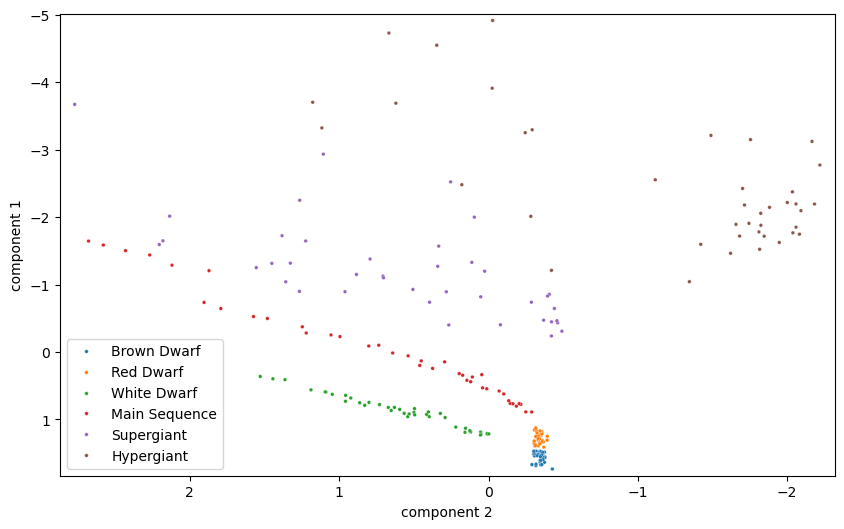

In [76]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=comp_new[:,1],y=comp_new[:,0], s=7, hue=labels)
#whit sns.scatterplot you can put the labels!!
plt.xlim(np.max(comp_new[:,1])+0.1,np.min(comp_new[:,1])-0.1)
plt.ylim(np.max(comp_new[:,0])+0.1,np.min(comp_new[:,0])-0.1)
plt.ylabel('component 1')
plt.xlabel('component 2')
plt.show()

Supergiant and Hypergiant are still a bit mixed but all the others stars types are well separated, good.

## Screen plots with 4 components

In [101]:
pca_4 = PCA(4) 
pca_4.fit(data) 

eigenvalues = pca_4.transform(data)
mean = pca_4.mean_
eigenvectors = pca_4.components_

print(eigenvalues.shape)
print(eigenvectors.shape)

comp_4 = pca_4.fit_transform(data)
evals = pca_4.explained_variance_ratio_ 

(240, 4)
(4, 4)


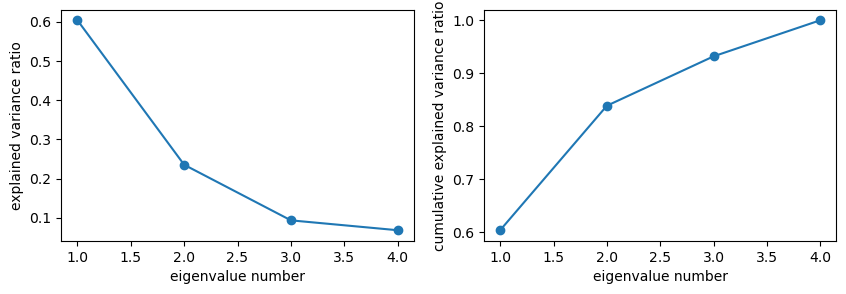

In [106]:
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)

ax.plot([1,2,3,4], evals)
ax.scatter([1,2,3,4], evals)

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)

ax.plot([1,2,3,4], evals.cumsum())
ax.scatter([1,2,3,4], evals.cumsum())

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()

In [109]:
[print(f"The {i+1} component explains {100 * evals[i]:.1f}%  of the variance in the data and the comulative one is {100*(evals.cumsum()[i]):.1f}%") for i in range(4)]

The 1 component explains 60.4%  of the variance in the data and the comulative one is 60.4%
The 2 component explains 23.5%  of the variance in the data and the comulative one is 83.9%
The 3 component explains 9.3%  of the variance in the data and the comulative one is 93.2%
The 4 component explains 6.8%  of the variance in the data and the comulative one is 100.0%


[None, None, None, None]